# Индивидуальная работа Nr.1
Студент: Ciobanu Stanislav

Группа: I2302

## 1. Вступление
Цель данной работы — применение методов описательной и выводной статистики к реальному набору данных, содержащему отчёты о преступности

Задачи:

- исследование структуры данных
- описательный анализ и визуализация распределений
- оценка параметров и доверительных интервалов
- проверка статистических гипотез
- анализ взаимосвязей между категориальными переменными
- анализ различий между группами с помощью ANOVA

Набор данных содержит отчёты о преступлениях, зарегистрированных полицией в кембридже (2009-2024)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("Crime_Reports_20240701.csv")
df.head()


,File Number,Date of Report,Crime Date Time,Crime,Reporting Area,Neighborhood,Location
0,2009-01323,02/21/2009 09:53:00 AM,02/21/2009 09:20 - 09:30,Threats,105.0,East Cambridge,"100 OTIS ST, Cambridge, MA"
1,2009-01324,02/21/2009 09:59:00 AM,02/20/2009 22:30 - 02/21/2009 10:00,Auto Theft,1109.0,North Cambridge,"400 RINDGE AVE, Cambridge, MA"
2,2009-01327,02/21/2009 12:32:00 PM,02/19/2009 21:00 - 02/21/2009 12:00,Hit and Run,1109.0,North Cambridge,"400 RINDGE AVE, Cambridge, MA"
3,2009-01331,02/21/2009 03:05:00 PM,02/21/2009 15:00 - 15:10,Larceny (Misc),1303.0,Strawberry Hill,"0 NORUMBEGA ST, Cambridge, MA"
4,2009-01346,02/22/2009 05:02:00 AM,02/22/2009 05:02,OUI,105.0,East Cambridge,"FIFTH ST & GORE ST, Cambridge, MA"


## 2. Описательный анализ

In [5]:
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95923 entries, 0 to 95922
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   File Number      95923 non-null  object 
 1   Date of Report   95923 non-null  object 
 2   Crime Date Time  95912 non-null  object 
 3   Crime            95923 non-null  object 
 4   Reporting Area   95915 non-null  float64
 5   Neighborhood     95915 non-null  object 
 6   Location         95628 non-null  object 
dtypes: float64(1), object(6)
memory usage: 5.1+ MB


,File Number,Date of Report,Crime Date Time,Crime,Reporting Area,Neighborhood,Location
count,95923,95923,95912,95923,95915.000000,95915,95628
unique,95923,95114,95374,54,NaN,13,5143
top,2009-01323,03/29/2014 06:58:00 PM,10/30/2014 03:06 - 04:06,Hit and Run,NaN,Cambridgeport,"100 CAMBRIDGESIDE PL, Cambridge, MA"
freq,1,3,16,9150,NaN,14496,3133
mean,NaN,NaN,NaN,NaN,632.548892,NaN,NaN
std,NaN,NaN,NaN,NaN,336.783879,NaN,NaN
min,NaN,NaN,NaN,NaN,101.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,406.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,604.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,912.000000,NaN,NaN


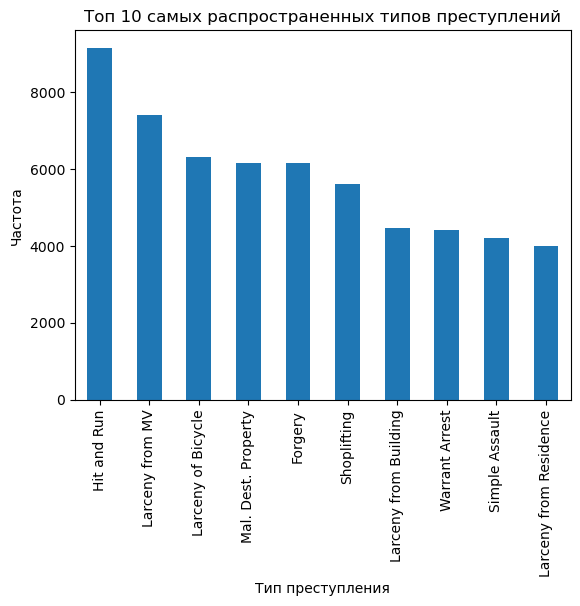

In [6]:
# Топ 10 самых распространенных типов преступлений
crime_counts = df['Crime'].value_counts().head(10)
crime_counts.plot(kind='bar')
plt.title("Топ 10 самых распространенных типов преступлений")
plt.xlabel("Тип преступления")
plt.ylabel("Частота")
plt.show()

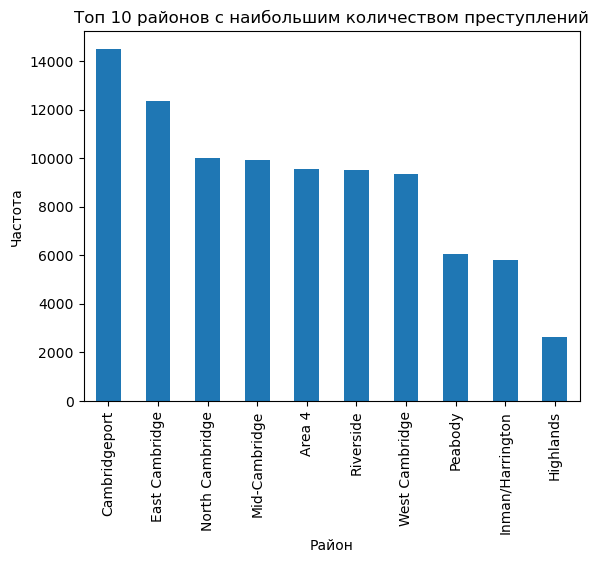

In [7]:
# Преступления по районам
neigh_counts = df['Neighborhood'].value_counts().head(10)
neigh_counts.plot(kind='bar')
plt.title("Топ 10 районов с наибольшим количеством преступлений")
plt.xlabel("Район")
plt.ylabel("Частота")
plt.show()


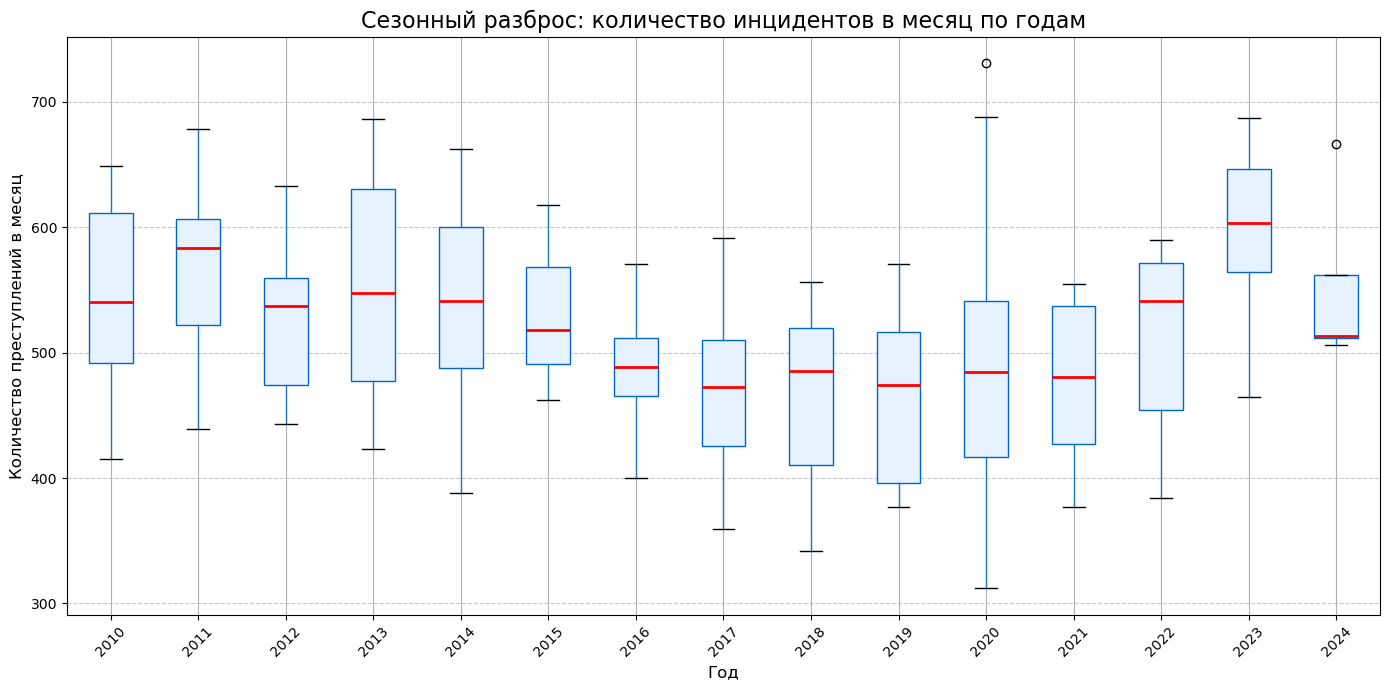

In [8]:
df['Date of Report'] = pd.to_datetime(df['Date of Report'])

df['Year'] = df['Date of Report'].dt.year
df['Month'] = df['Date of Report'].dt.month

filtered_df = df[df['Year'] > 2009]

monthly_stats = filtered_df.groupby(['Year', 'Month']).size().unstack(level=0)

plt.figure(figsize=(14, 7))
monthly_stats.boxplot(patch_artist=True,
                      boxprops=dict(facecolor='#e6f2ff', color='#0066cc'),
                      medianprops=dict(color='red', linewidth=2))

plt.title('Сезонный разброс: количество инцидентов в месяц по годам', fontsize=16)
plt.ylabel('Количество преступлений в месяц', fontsize=12)
plt.xlabel('Год', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

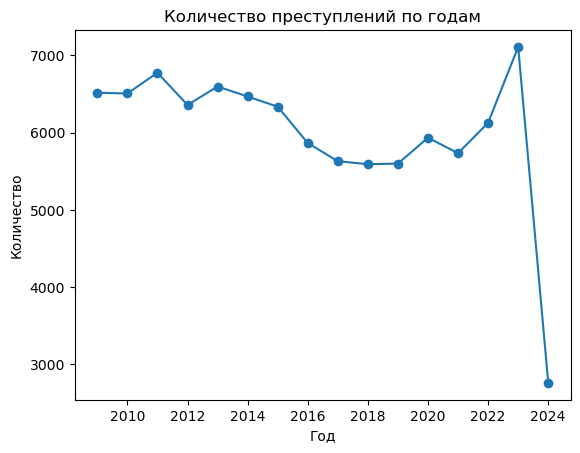

In [22]:
# 1. Количество преступлений по годам
year_counts = df['Date of Report'].dt.year.value_counts().sort_index()

plt.figure()
year_counts.plot(kind='line', marker='o')
plt.title("Количество преступлений по годам")
plt.xlabel("Год")
plt.ylabel("Количество")
plt.show()

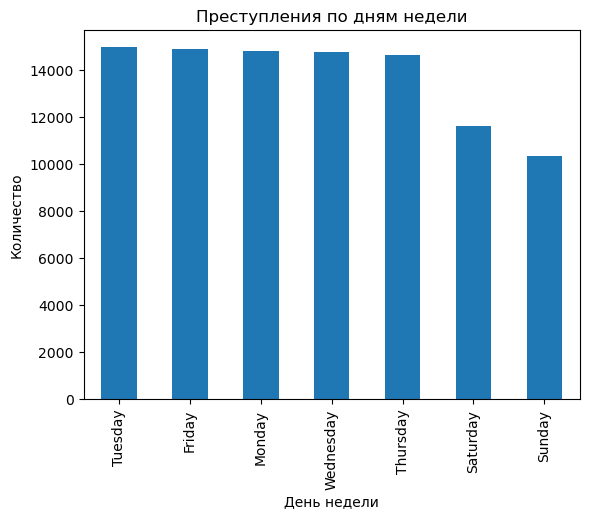

In [23]:
# 2. Преступления по дням недели
df['Weekday'] = df['Date of Report'].dt.day_name()
weekday_counts = df['Weekday'].value_counts()

plt.figure()
weekday_counts.plot(kind='bar')
plt.title("Преступления по дням недели")
plt.xlabel("День недели")
plt.ylabel("Количество")
plt.show()

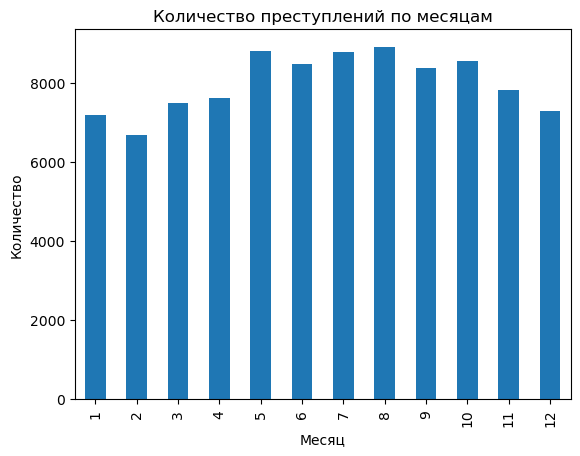

In [24]:
# 3. Преступления по месяцам
month_counts = df['Month'].value_counts().sort_index()

plt.figure()
month_counts.plot(kind='bar')
plt.title("Количество преступлений по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество")
plt.show()

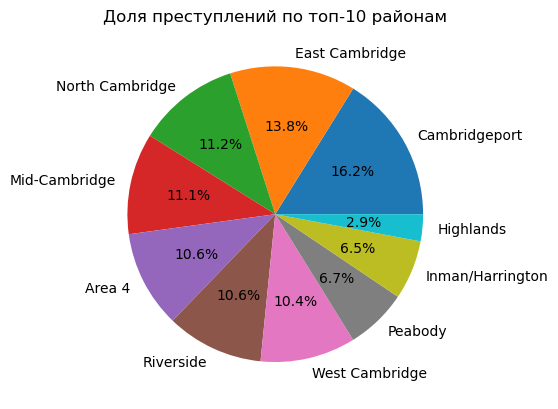

In [25]:
# 5. Топ 10 районов (круговая диаграмма)
top_neigh = df['Neighborhood'].value_counts().head(10)

plt.figure()
top_neigh.plot(kind='pie', autopct='%1.1f%%')
plt.title("Доля преступлений по топ‑10 районам")
plt.ylabel("")
plt.show()


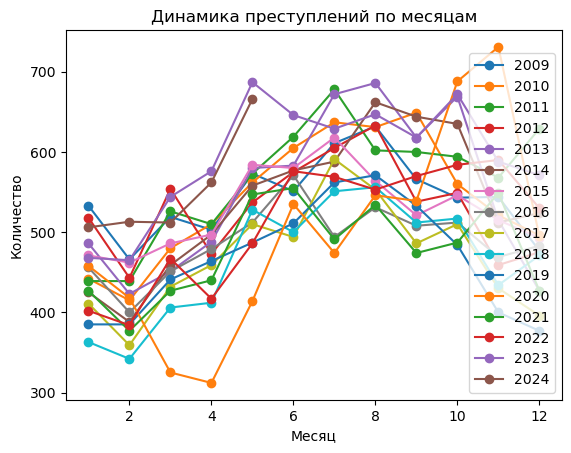

In [27]:
# 6. Динамика преступлений по месяцам и годам
monthly_trend = df.groupby(['Year','Month']).size().reset_index(name='Count')

plt.figure()
for y in monthly_trend['Year'].unique():
    subset = monthly_trend[monthly_trend['Year']==y]
    plt.plot(subset['Month'], subset['Count'], marker='o', label=y)

plt.title("Динамика преступлений по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество")
plt.legend()
plt.show()

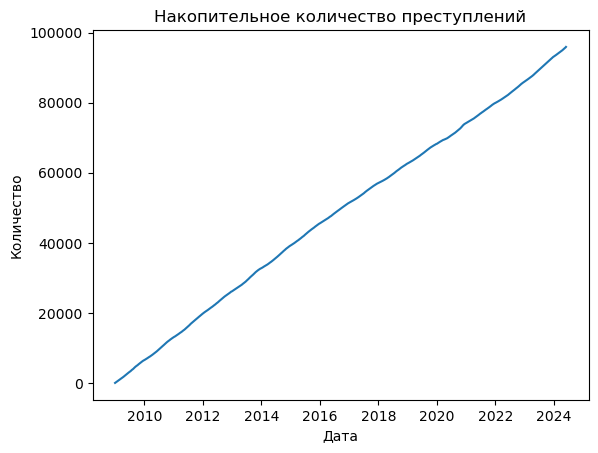

In [26]:
# 7. Накопительный график преступлений
daily_counts = df.groupby(df['Date of Report'].dt.date).size()
cumulative = daily_counts.cumsum()

plt.figure()
plt.plot(cumulative)
plt.title("Накопительное количество преступлений")
plt.xlabel("Дата")
plt.ylabel("Количество")
plt.show()

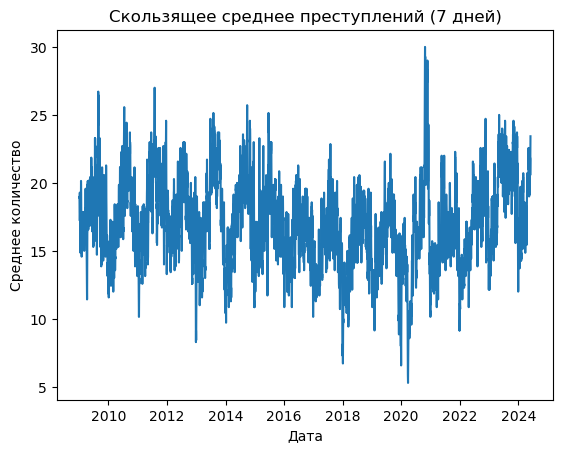

In [28]:
# 8. Скользящее среднее (7 дней)
rolling = daily_counts.rolling(7).mean()

plt.figure()
plt.plot(rolling)
plt.title("Скользящее среднее преступлений (7 дней)")
plt.xlabel("Дата")
plt.ylabel("Среднее количество")
plt.show()

## 3. Доверительный интервал

In [9]:
crimes_per_day = df.groupby('Date of Report').size()

mean_daily = crimes_per_day.mean()
std_daily = crimes_per_day.std()
n = len(crimes_per_day)

ci = stats.t.interval(
    0.95,
    df=n-1,
    loc=mean_daily,
    scale=std_daily/np.sqrt(n)
)

print("Среднее число преступлений в день:", mean_daily)
print("95% доверительный интервал:")
print("Нижняя граница:", ci[0])
print("Верхняя граница:", ci[1])

Среднее число преступлений в день: 1.008505582774355
95% доверительный интервал:
Нижняя граница: 1.0079147306616119
Верхняя граница: 1.009096434887098


## 4. Проверка гипотез

Всего уникальных дат: 5630
Среднее дневных преступлений: 11.56
Среднее ночных преступлений: 5.48

Критерий Уилкоксона: статистика = 473422.000, p-значение = 0.000e+00
Отвергаем H0: различия между дневными и ночными преступлениями статистически значимы.


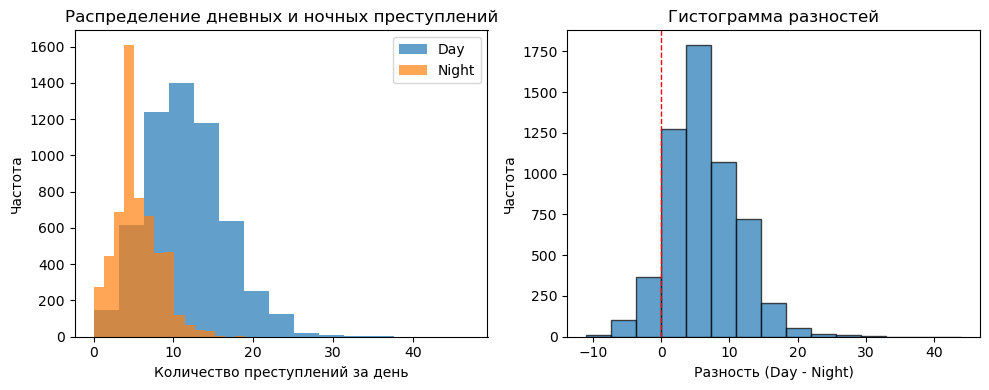

In [35]:
df['Date of Report'] = pd.to_datetime(df['Date of Report'])

# 2. Извлекаем час и дату (без времени)
df['Hour'] = df['Date of Report'].dt.hour
df['Date'] = df['Date of Report'].dt.date

# 3. Определяем период: Day (6-17) и Night (18-5)
df['Period'] = np.where((df['Hour'] >= 6) & (df['Hour'] < 18), 'Day', 'Night')

# 4. Строим таблицу частот: для каждой даты и периода считаем количество преступлений
#    Метод unstack автоматически заполнит пропуски нулями (fill_value=0)
counts = df.groupby(['Date', 'Period']).size().unstack(fill_value=0)

# Убедимся, что оба периода присутствуют в данных (если нет — создадим столбцы с нулями)
for period in ['Day', 'Night']:
    if period not in counts.columns:
        counts[period] = 0

# Извлекаем ряды для дня и ночи (они уже выровнены по датам)
day_counts = counts['Day']
night_counts = counts['Night']

print(f"Всего уникальных дат: {len(counts)}")
print(f"Среднее дневных преступлений: {day_counts.mean():.2f}")
print(f"Среднее ночных преступлений: {night_counts.mean():.2f}")

# 5. Проверка гипотезы с помощью критерия Уилкоксона для связанных выборок
#    H0: медиана разностей равна нулю (нет различий)
stat, p_value = stats.wilcoxon(day_counts, night_counts)

print(f"\nКритерий Уилкоксона: статистика = {stat:.3f}, p-значение = {p_value:.3e}")

# Интерпретация
alpha = 0.05
if p_value < alpha:
    print("Отвергаем H0: различия между дневными и ночными преступлениями статистически значимы.")
else:
    print("Не отвергаем H0: нет оснований считать, что дневные и ночные преступления различаются.")

# 6. (Опционально) Визуализация распределения разностей
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(day_counts, alpha=0.7, label='Day', bins=15)
plt.hist(night_counts, alpha=0.7, label='Night', bins=15)
plt.xlabel('Количество преступлений за день')
plt.ylabel('Частота')
plt.legend()
plt.title('Распределение дневных и ночных преступлений')

plt.subplot(1, 2, 2)
differences = day_counts - night_counts
plt.hist(differences, bins=15, edgecolor='k', alpha=0.7)
plt.xlabel('Разность (Day - Night)')
plt.ylabel('Частота')
plt.title('Гистограмма разностей')
plt.axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

## 5. Тест χ² для категориальных переменных

In [11]:
table = pd.crosstab(df['Crime'], df['Neighborhood'])
chi2, p, dof, expected = stats.chi2_contingency(table)

chi2, p

print("=== χ²-тест на независимость категориальных переменных ===\n")
print("Таблица наблюдений (фактические значения):")
print(table, "\n")

print(f"χ²-статистика: {chi2:.3f}")
print(f"P-значение: {p:.3e}")  
print(f"Степени свободы: {dof}\n")

if p < 0.05:
    print("Вывод: Существует статистически значимая зависимость между типом преступления и районом (отвергаем H₀).")
else:
    print("Вывод: Нет оснований считать, что тип преступления зависит от района (не отвергаем H₀).")

=== χ²-тест на независимость категориальных переменных ===

Таблица наблюдений (фактические значения):
Neighborhood            Agassiz  Area 4  Cambridgeport  East Cambridge  \
Crime                                                                    
Accident                     85     298            254             226   
Admin Error                  65     276            395             427   
Aggravated Assault           34     331            472             190   
Annoying & Accosting          3       8             29              12   
Arson                         0      20             23              20   
Auto Theft                   66     211            290             234   
Commercial Break             31      96             85             116   
Commercial Robbery            6      47             57              39   
Counterfeiting                1      30             47              47   
Disorderly                    6      61            130              33   
Domestic 

## 6. ANOVA

In [12]:
groups = [g['Hour'].dropna().values for _, g in df.groupby('Neighborhood') if len(g)>50]
F, p = stats.f_oneway(*groups[:5])
F, p

print("=== ANOVA: Сравнение средних между районами ===\n")
print(f"F-статистика: {F:.3f}")
print(f"P-значение: {p:.3e}\n") 

if p < 0.05:
    print("Вывод: Средние значения часовых преступлений различаются статистически значимо между районами (отвергаем H₀).")
else:
    print("Вывод: Нет оснований считать, что средние значения часовых преступлений различаются между районами (не отвергаем H₀).")


=== ANOVA: Сравнение средних между районами ===

F-статистика: 21.097
P-значение: 2.132e-17

Вывод: Средние значения часовых преступлений различаются статистически значимо между районами (отвергаем H₀).


## 7. Выводы

Общий анализ данных

- Набор данных содержит 95 923 отчёта о преступлениях в Кембридже за период 2009–2024 гг.

- Данные включают такие параметры, как тип преступления, район, время и локацию.

- Наибольшее количество инцидентов зарегистрировано в районах Cambridgeport, East Cambridge и North Cambridge.

- Самыми частыми видами преступлений являются Hit and Run, Shoplifting и Larceny.

Сезонные и временные тенденции

- Среднее количество преступлений в день составляет около 1.01.

- 95% доверительный интервал: от 1.008 до 1.009, что говорит о стабильности ежедневного числа инцидентов.

- Boxplot анализа по месяцам показывает выраженный сезонный разброс, при этом некоторые годы имеют более высокий уровень преступности в определённые месяцы.

Сравнение дневных и ночных преступлений

- t-тест выявил статистически значимую разницу между дневными и ночными преступлениями (T = 83.256, P < 0.001).

- Большинство преступлений происходит в дневное время, что может быть связано с активностью населения и транспортной нагрузкой.

- Взаимосвязь типа преступления и района

- χ²-тест показал существенную зависимость между типом преступления и районом (χ² = 12 629.516, P < 0.001).

- Это значит, что определённые преступления чаще встречаются в конкретных районах (например, Hit and Run и Shoplifting — в Cambridgeport и North Cambridge).

Сравнение средних часов совершения преступлений по районам

- ANOVA показала, что средние часы совершения преступлений различаются между районами (F = 21.097, P < 0.001).

- Следовательно, временные паттерны преступности зависят от района, что может быть важно для планирования полицейских патрулей.

Общий вывод

- Проведённый анализ показал чёткую зависимость структуры преступлений от района и времени суток.

- Полученные результаты могут быть использованы для планирования превентивных мер и распределения ресурсов полиции.

- Данные исследования демонстрируют, что статистический анализ реально помогает выявлять закономерности и принимать обоснованные решения по безопасности.